In [1]:
import functools
import matplotlib.pyplot as plt
import numpy as np
import torch
import seaborn as sns

from network import Net, NetDiscovery
from diff_equations import grad, cooling_law
from sklearn.model_selection import train_test_split

sns.set_theme()
torch.manual_seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if torch.cuda.is_available():
    device = torch.device('cuda')
    torch.backends.cudnn.benchmark = True
else:
    device = torch.device('cpu')

if torch.cuda.is_available():
    torch.empty(1).to(DEVICE)

print(f"PyTorch will use: {DEVICE}")

PyTorch will use: cuda


# Parameters

In [2]:
number_of_points = 100
noise_coeff = 2

pinn_collocation_points = 1000
parameter_discovery_collocation_points = 1000

pinn_loss2_weight = 0.5
parameter_discovery_loss_2_weight = 0.5

vanila_epochs = 20000
pinn_epochs = 20000
parameter_discovery_epochs = 20000

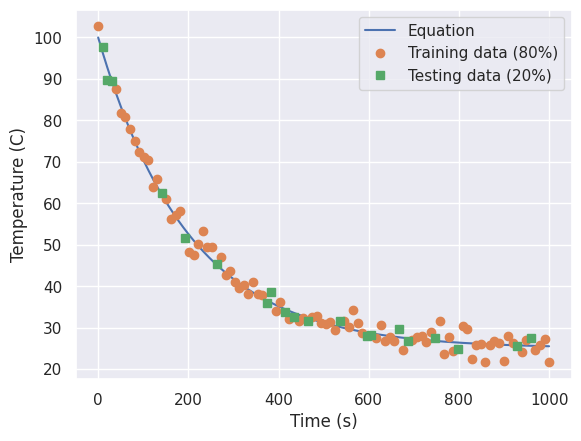

In [3]:
np.random.seed(10)

Tenv = 25
T0 = 100
R = 0.005


times = np.linspace(0, 1000, 1000)
eq = functools.partial(cooling_law, Tenv=Tenv, T0=T0, R=R)
temps = eq(times)

# Make training data
t = np.linspace(0, 1000, number_of_points)
T = eq(t) + noise_coeff * np.random.randn(number_of_points)

x_train, x_test, y_train, y_test = train_test_split(t, T, test_size=0.2, random_state=10)

plt.plot(times, temps)
plt.plot(x_train, y_train, 'o') 
plt.plot(x_test, y_test, 's')   
plt.legend(['Equation', 'Training data (80%)', 'Testing data (20%)'])
plt.ylabel('Temperature (C)')
plt.xlabel('Time (s)')
plt.show()

# Vanilla Networks

Epoch 0/20000, loss: 2230.38
Epoch 2000/20000, loss: 1138.70
Epoch 4000/20000, loss: 850.79
Epoch 6000/20000, loss: 284.26
Epoch 8000/20000, loss: 63.18
Epoch 10000/20000, loss: 19.10
Epoch 12000/20000, loss: 6.19
Epoch 14000/20000, loss: 3.92
Epoch 16000/20000, loss: 3.84
Epoch 18000/20000, loss: 3.74


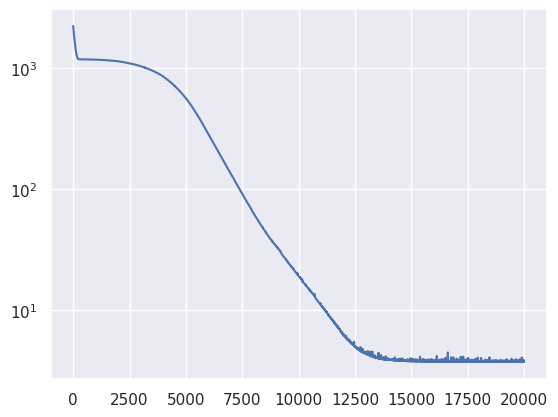

In [4]:
net = Net(1, 1, epochs=vanila_epochs, lr=1e-5).to(DEVICE)

losses = net.fit(x_train, y_train)

plt.plot(losses)
plt.yscale('log')

Mean Squared Error: 11.6898


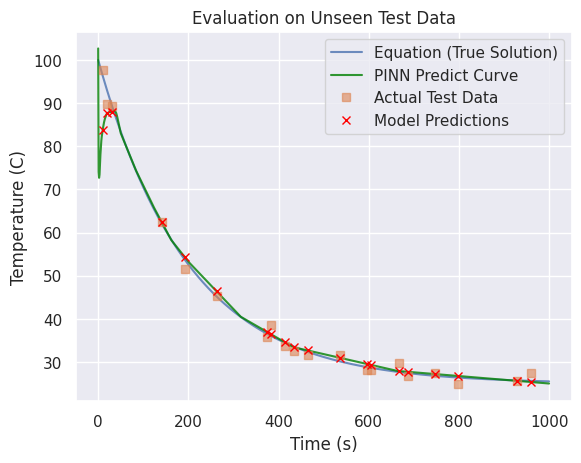

In [5]:
# Predict specifically for the test points to calculate MSE
T_pred = net.predict(x_test)
test_mse = np.mean((T_pred.flatten() - y_test)**2)
print(f"Mean Squared Error: {test_mse:.4f}")

# Predict across the entire continuous time domain
continuous_preds = net.predict(times)

plt.figure()

# Plot the continuous curves
plt.plot(times, temps, label='Equation (True Solution)', alpha=0.8)
plt.plot(times, continuous_preds, label='PINN Predict Curve', color='green', alpha=0.8)

# Plot the discrete test points
plt.plot(x_test, y_test, 's', label='Actual Test Data', alpha=0.6)
plt.plot(x_test, T_pred, 'x', label='Model Predictions', color='red')

plt.legend()
plt.ylabel('Temperature (C)')
plt.xlabel('Time (s)')
plt.title('Evaluation on Unseen Test Data')
plt.show()

In [6]:
def l2_reg(model: torch.nn.Module):
    return torch.sum(sum([p.pow(2.) for p in model.parameters()]))

Epoch 0/20000, loss: 2695.07
Epoch 2000/20000, loss: 1774.00
Epoch 4000/20000, loss: 1422.22
Epoch 6000/20000, loss: 806.84
Epoch 8000/20000, loss: 593.03
Epoch 10000/20000, loss: 540.81
Epoch 12000/20000, loss: 512.61
Epoch 14000/20000, loss: 487.75
Epoch 16000/20000, loss: 464.53
Epoch 18000/20000, loss: 442.86


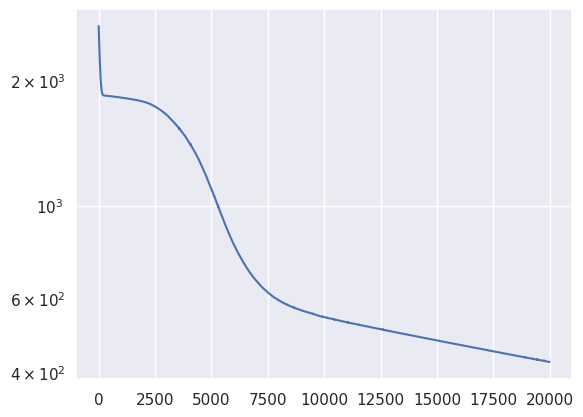

In [7]:
netreg = Net(1,1, loss2=l2_reg, epochs=vanila_epochs, lr=1e-5).to(DEVICE)

losses = netreg.fit(x_train, y_train)

plt.plot(losses)
plt.yscale('log')

Mean Squared Error: 22.2010


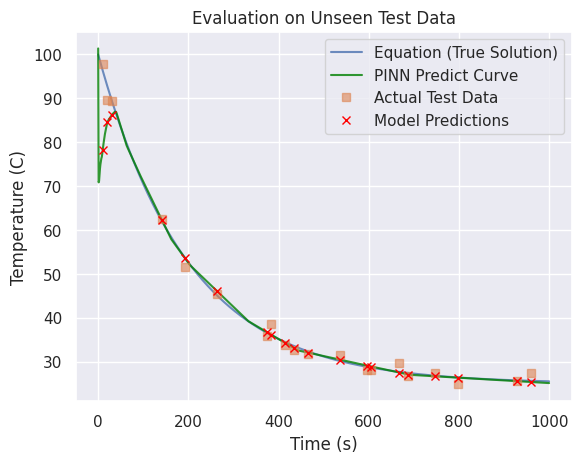

In [8]:
# Predict specifically for the test points to calculate MSE
T_pred = netreg.predict(x_test)
test_mse = np.mean((T_pred.flatten() - y_test)**2)
print(f"Mean Squared Error: {test_mse:.4f}")

# Predict across the entire continuous time domain
continuous_preds = netreg.predict(times)

plt.figure()

# Plot the continuous curves
plt.plot(times, temps, label='Equation (True Solution)', alpha=0.8)
plt.plot(times, continuous_preds, label='PINN Predict Curve', color='green', alpha=0.8)

# Plot the discrete test points
plt.plot(x_test, y_test, 's', label='Actual Test Data', alpha=0.6)
plt.plot(x_test, T_pred, 'x', label='Model Predictions', color='red')

plt.legend()
plt.ylabel('Temperature (C)')
plt.xlabel('Time (s)')
plt.title('Evaluation on Unseen Test Data')
plt.show()

# PINN

In [9]:
def physics_loss(model: torch.nn.Module, n_points=pinn_collocation_points):
    ts = torch.linspace(0, 1000, steps=n_points).view(-1,1).requires_grad_(True).to(DEVICE)
    temps = model(ts)
    dT = grad(temps, ts)[0]
    pde = R*(Tenv - temps) - dT

    return torch.mean(pde**2)

Epoch 0/20000, loss: 2392.49
Epoch 2000/20000, loss: 1154.88
Epoch 4000/20000, loss: 933.18
Epoch 6000/20000, loss: 341.58
Epoch 8000/20000, loss: 70.95
Epoch 10000/20000, loss: 18.31
Epoch 12000/20000, loss: 6.17
Epoch 14000/20000, loss: 4.30
Epoch 16000/20000, loss: 4.05
Epoch 18000/20000, loss: 3.99


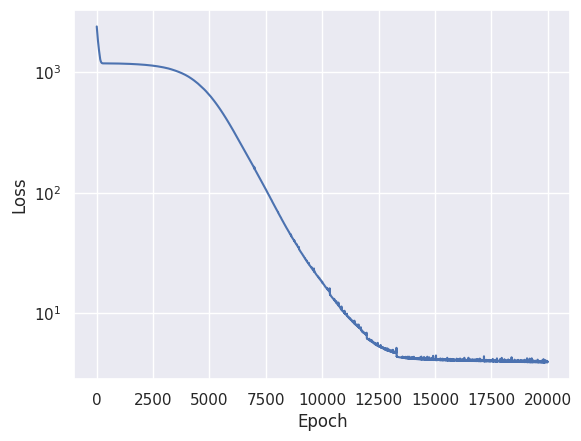

In [10]:
net = Net(1, 1, loss2=physics_loss, epochs=pinn_epochs, loss2_weight=pinn_loss2_weight, lr=1e-5).to(DEVICE)

losses = net.fit(x_train, y_train)

plt.plot(losses)
plt.yscale('log')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.show()

Text(0.5, 0, 'Time (s)')

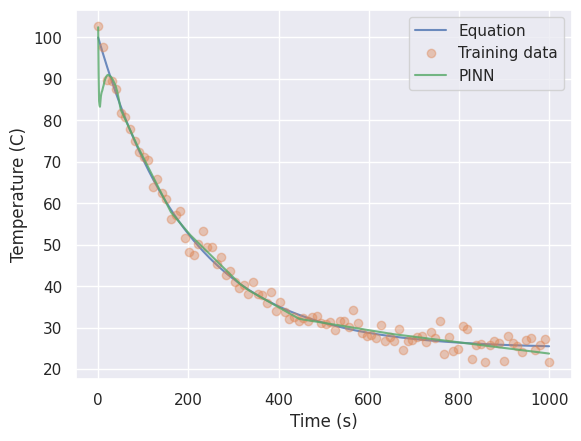

In [ ]:
preds = net.predict(times)

plt.plot(times, temps, alpha=0.8)
plt.plot(t, T, 'o',alpha=0.4)
plt.plot(times, preds, alpha=0.8)
plt.legend(labels=['Equation','Training data', 'PINN'])
plt.ylabel('Temperature (C)')
plt.xlabel('Time (s)')

Mean Squared Error: 6.9082


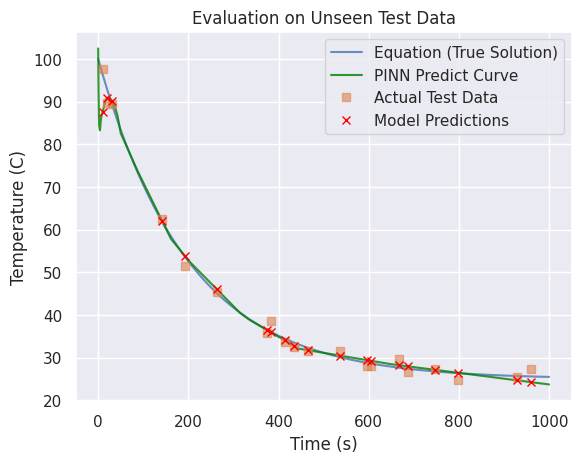

In [12]:
# Predict specifically for the test points to calculate MSE
T_pred = net.predict(x_test)
test_mse = np.mean((T_pred.flatten() - y_test)**2)
print(f"Mean Squared Error: {test_mse:.4f}")

# Predict across the entire continuous time domain
continuous_preds = net.predict(times)

plt.figure()

# Plot the continuous curves
plt.plot(times, temps, label='Equation (True Solution)', alpha=0.8)
plt.plot(times, continuous_preds, label='PINN Predict Curve', color='green', alpha=0.8)

# Plot the discrete test points
plt.plot(x_test, y_test, 's', label='Actual Test Data', alpha=0.6)
plt.plot(x_test, T_pred, 'x', label='Model Predictions', color='red')

plt.legend()
plt.ylabel('Temperature (C)')
plt.xlabel('Time (s)')
plt.title('Evaluation on Unseen Test Data')
plt.show()

# Parameter discovery

In [13]:
def physics_loss_discovery(model: torch.nn.Module, n_points=parameter_discovery_collocation_points):

    ts = torch.linspace(0, 1000, steps=n_points).view(-1,1).requires_grad_(True).to(DEVICE)

    temps = model(ts)
    dT = grad(temps, ts)[0]
    pde = model.r * (Tenv - temps) - dT

    return torch.mean(pde**2)

Epoch 0/20000, loss: 2465.35
Epoch 2000/20000, loss: 1150.14
Epoch 4000/20000, loss: 700.71
Epoch 6000/20000, loss: 113.96
Epoch 8000/20000, loss: 11.84
Epoch 10000/20000, loss: 5.17
Epoch 12000/20000, loss: 4.51
Epoch 14000/20000, loss: 4.27
Epoch 16000/20000, loss: 4.21
Epoch 18000/20000, loss: 3.97


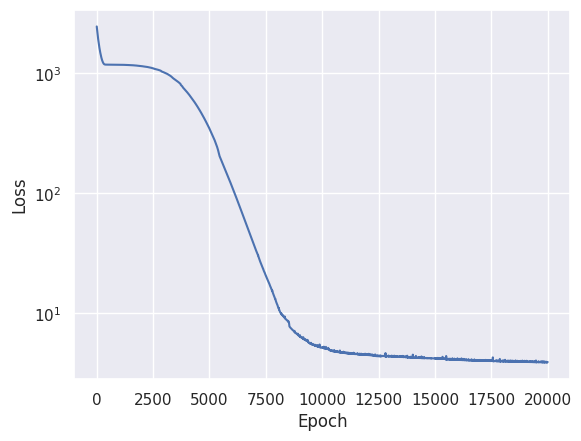

In [14]:
netdisc = NetDiscovery(1, 1, loss2=physics_loss_discovery, loss2_weight=parameter_discovery_loss_2_weight, epochs=parameter_discovery_epochs, lr=1e-5).to(DEVICE)

losses = netdisc.fit(x_train, y_train)

plt.plot(losses)
plt.yscale('log')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.show()

Parameter containing:
tensor([0.0055], device='cuda:0', requires_grad=True)


Text(0.5, 0, 'Time (s)')

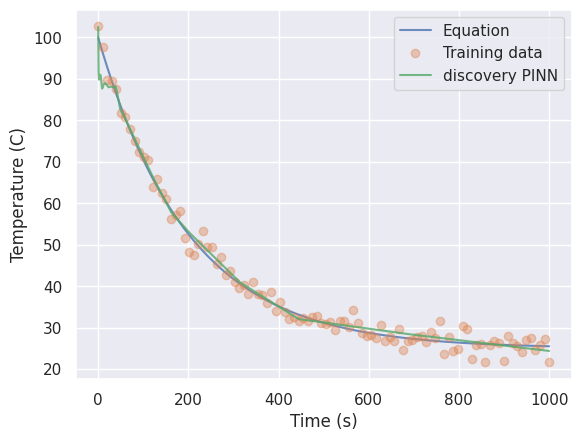

In [15]:
preds = netdisc.predict(times)
print(netdisc.r)

plt.plot(times, temps, alpha=0.8)
plt.plot(t, T, 'o', alpha=0.4)
plt.plot(times, preds, alpha=0.8)
plt.legend(labels=['Equation','Training data', 'discovery PINN'])
plt.ylabel('Temperature (C)')
plt.xlabel('Time (s)')

Mean Squared Error: 6.7136
Discovered Cooling Rate (R): 0.005541
True Cooling Rate (R): 0.005


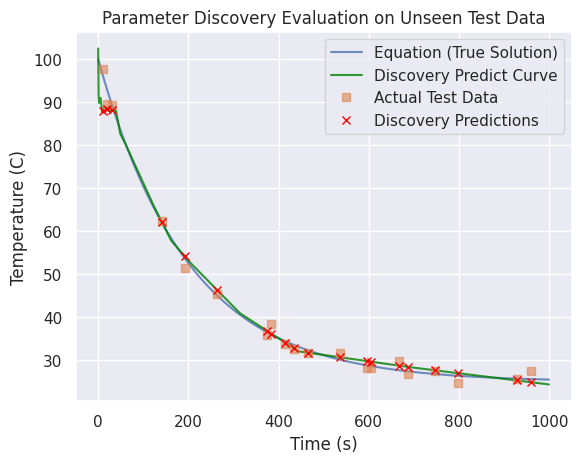

In [16]:
# Predict specifically for the test points to calculate MSE
T_pred_disc = netdisc.predict(x_test)

test_mse_disc = np.mean((T_pred_disc.flatten() - y_test)**2)
discovered_r = netdisc.r.item()
true_r = 0.005

print(f"Mean Squared Error: {test_mse_disc:.4f}")
print(f"Discovered Cooling Rate (R): {discovered_r:.6f}")
print(f"True Cooling Rate (R): {true_r}")

# Predict across the entire continuous time domain
continuous_preds_disc = netdisc.predict(times)

plt.figure()

# Plot the continuous curves
plt.plot(times, temps, label='Equation (True Solution)', alpha=0.8)
plt.plot(times, continuous_preds_disc, label='Discovery Predict Curve', color='green', alpha=0.8)

# Plot the discrete test points
plt.plot(x_test, y_test, 's', label='Actual Test Data', alpha=0.6)
plt.plot(x_test, T_pred_disc, 'x', label='Discovery Predictions', color='red')

plt.legend()
plt.ylabel('Temperature (C)')
plt.xlabel('Time (s)')
plt.title('Parameter Discovery Evaluation on Unseen Test Data')
plt.show()